# Structure Function and decorrelation scale functions Testing  

**Purpose**: Code for testing functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Set path to access python functions
sys.path.append('/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/')

#--- Luke's Python Functions ---# 
from structure_functions import compute_structure_function, compute_decor_scale_struct

def plot_structfit_todd(r, S2, out, ax=None):
    """
    Plot observed 2nd-order structure function and the fitted Todd (2013) model.
    """

    # Import functions 
    import numpy as np
    import matplotlib.pyplot as plt
    from structure_functions import _exp_sf_model

    r = np.asarray(r, float)
    S2 = np.asarray(S2, float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    # Use the exact points that were used in the fit
    r_fit = out["r_used"]
    S2_fit = out["S2_used"]

    # Evaluate model on a smooth grid spanning the fit range
    r_grid = np.linspace(np.nanmin(r_fit), np.nanmax(r_fit), 400)
    S2_model = _exp_sf_model(r_grid, out["sigma2"], out["L"], out["offset"])

    # Plot all data lightly for context
    ax.plot(r, S2, ".", alpha=0.25, label="S2 (all)")

    # Plot the points actually used in the fit
    ax.plot(r_fit, S2_fit, "o", ms=4, label="S2 (fit points)")

    # Plot the fitted curve
    ax.plot(r_grid, S2_model, "-", lw=2, label="Todd fit")

    # Helpful reference lines
    plateau = 2.0 * out["sigma2"] + out["offset"]
    ax.axhline(plateau, ls="--", lw=1, alpha=0.8, label="Plateau ~ 2σ² + offset")
    ax.axvline(out["L"], ls="--", lw=1, alpha=0.8, label=f"L = {out['L']:.3g}")

    ax.set_xlabel("Separation r")
    ax.set_ylabel(r"$D_2(r)$")
    ax.set_title("Todd (2013): Exponential fit to structure function")
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.3)
    #ax.set_xlim([0, None])
    ax.set_ylim([0, None])

    return fig, ax


def plot_structfit_lee(r, S2, out, var0, normalize=True, ax=None):
    """
    Plot Lee (2011) fit in correlation/covariance space derived from the structure function.
    """

    # Import functions 
    import numpy as np
    import matplotlib.pyplot as plt
    from structure_functions import _cosexp_corr_model

    r = np.asarray(r, float)
    S2 = np.asarray(S2, float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    else:
        fig = ax.figure

    # Use the exact points used in the fit
    r_fit = out["r_used"]
    S2_fit = out["S2_used"]

    # Convert S2 -> autocovariance, then to correlation if requested
    C_fit = var0 - 0.5 * S2_fit
    y_fit = (C_fit / var0) if normalize else C_fit

    # Smooth grid for model curve
    r_grid = np.linspace(np.nanmin(r_fit), np.nanmax(r_fit), 600)
    y_model = _cosexp_corr_model(r_grid, out["L"], out["lam"], out["amp"], out["offset"])

    # Envelope (what you'd expect the oscillations to decay within)
    env = np.abs(out["amp"]) * np.exp(-r_grid / out["L"])
    y_upper = out["offset"] + env
    y_lower = out["offset"] - env

    # Plot fit-target points and model
    ax.plot(r_fit, y_fit, "o", ms=4, label=f"{out.get('fit_target','fit target')} (fit points)")
    ax.plot(r_grid, y_model, "-", lw=2, label="Lee fit")
    ax.plot(r_grid, y_upper, "--", lw=1, alpha=0.8, label="Envelope ±|amp| e^{-r/L}")
    ax.plot(r_grid, y_lower, "--", lw=1, alpha=0.8)

    # Reference lines
    ax.axvline(out["L"], ls="--", lw=1, alpha=0.8, label=f"L = {out['L']:.3g}")
    ax.axhline(out["offset"], ls=":", lw=1, alpha=0.8, label="Offset")

    ax.set_xlabel("Separation r")
    ax.set_ylabel("Correlation" if normalize else "Autocovariance")
    ax.set_title("Lee (2011): Cosine–exponential fit (derived from S2)")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

    return fig, ax


Generate synthetic structure function for Todd et al. (2013) approach 

Todd (synthetic) results:
    sigma2 = 1.527
         L = 19.825
    offset = 0.158


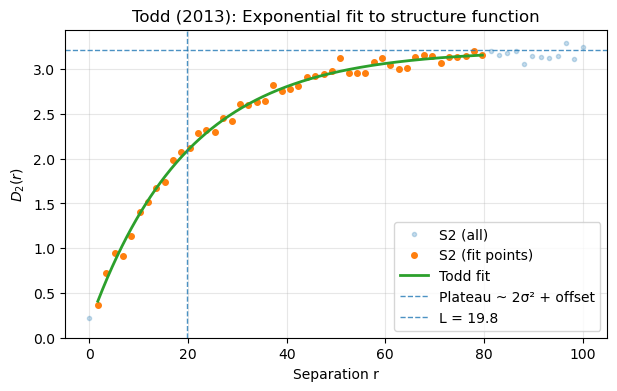

In [11]:
# -----------------------
# True parameters
# -----------------------
L_true = 20.0
sigma2_true = 1.5
offset_true = 0.2   # nugget / noise floor

# -----------------------
# Synthetic lag axis
# -----------------------
r = np.linspace(0, 100, 60)

# -----------------------
# Ideal Todd-style structure function
# -----------------------
S2 = 2.0 * sigma2_true * (1.0 - np.exp(-r / L_true)) + offset_true

# Add mild noise to mimic finite sampling
rng = np.random.default_rng(42)
S2 += 0.05 * sigma2_true * rng.standard_normal(S2.size)

# -----------------------
# Fit using your function
# -----------------------
out_todd = compute_decor_scale_struct(
    r,
    S2,
    method="todd2013",
    fit_range=(0, 80),
)

print("Todd (synthetic) results:")
for k, v in out_todd.items():
    if isinstance(v, float):
        print(f"  {k:>8s} = {v:.3f}")

# -----------------------
# Visual check
# -----------------------
plot_structfit_todd(r, S2, out_todd)
plt.show()


Generate synthetic structure function for Lee et al. (2011) approach 

Lee (synthetic) results:
         L = 0.965
       lam = 7.615
       amp = 848.863
    offset = -0.043


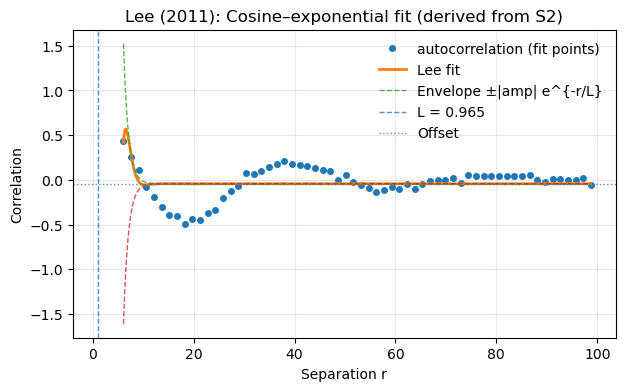

In [13]:
# -----------------------
# True parameters
# -----------------------
L_true = 25.0
lam_true = 40.0
sigma2_true = 2.0

# -----------------------
# Synthetic lag axis
# -----------------------
r = np.linspace(0, 120, 80)

# -----------------------
# True correlation and structure function
# -----------------------
rho = np.exp(-r / L_true) * np.cos(2.0 * np.pi * r / lam_true)
S2 = 2.0 * sigma2_true * (1.0 - rho)

# Add mild noise
rng = np.random.default_rng(123)
S2 += 0.05 * sigma2_true * rng.standard_normal(S2.size)

# Variance needed for Lee method
var0 = sigma2_true

# -----------------------
# Fit using your function
# -----------------------
out_lee = compute_decor_scale_struct(
    r,
    S2,
    method="lee2011",
    var0=var0,
    normalize=True,
    fit_range=(5, 100),
)

print("Lee (synthetic) results:")
for k, v in out_lee.items():
    if isinstance(v, float):
        print(f"  {k:>8s} = {v:.3f}")

# -----------------------
# Visual check
# -----------------------
plot_structfit_lee(r, S2, out_lee, var0=var0, normalize=True)
plt.show()
